In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
import torch
import numpy as np
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

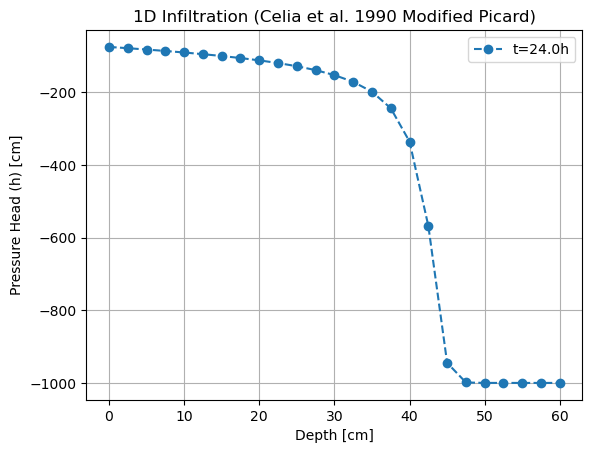

In [154]:
def solve_richards_1d_celia():
    # --- Parameters ---
    L = 60          # Domain length [cm]
    dz = 2.5       # Spatial step [cm]
    T = 3600*24       # Total time [s]
    dt = 400        # Time step [s]
    
    # Soil Properties (e.g., Silt Loam)
    theta_s = 0.368    # Saturated water content
    theta_r = 0.102    # Residual water content
    alpha = 0.0335       # van Genuchten parameter [1/cm]
    n_vg = 2        # van Genuchten parameter
    m_vg = 1 - 1/n_vg
    Ks = 0.00922          # Saturated hydraulic conductivity [cm/s]
    
    # Discretization
    z = np.arange(0, L+dz, dz)
    nz = len(z)
    h = np.full(nz, -1000.0) # Initial condition: dry soil (h = -1000 cm)
    
    # Boundary Conditions
    h_top = -75      # Dirichlet at top (nearly saturated)
    h_bot = -1000    # Dirichlet at bottom (dry)

    h[0] = h_top
    h[-1] = h_bot
    
    # Tolerance for Picard iteration
    tol = 1e-4
    max_iter = 50
    
    # --- Soil Functions ---
    def get_theta(h):
        # van Genuchten retention
        se = (1 + (alpha * np.abs(h))**n_vg)**(-m_vg)
        se = np.where(h < 0, se, 1.0)
        return theta_r + (theta_s - theta_r) * se

    def get_C(h):
        # Specific moisture capacity dTheta/dh
        abs_h = np.abs(h)
        C = (alpha * n_vg * m_vg * (theta_s - theta_r) * (alpha * abs_h)**(n_vg-1) * (1 + (alpha * abs_h)**n_vg)**(-m_vg - 1))
        return np.where(h < 0, C, 1e-10) # Small value for saturated case

    def get_K(h):
        # Mualem-van Genuchten conductivity
        se = (1 + (alpha * np.abs(h))**n_vg)**(-m_vg)
        se = np.where(h < 0, se, 1.0)
        return Ks * se**0.5 * (1 - (1 - se**(1/m_vg))**m_vg)**2

    # --- Time Stepping ---
    t = 0
    while t < T:
        h_n = h.copy()
        theta_n = get_theta(h_n)
        h_m = h.copy() # Initial guess for next time step
        
        for iteration in range(max_iter):
            # Evaluate properties at previous iteration level m
            C_m = get_C(h_m)
            K_m = get_K(h_m)
            theta_m = get_theta(h_m)
            
            # Conductivity at interfaces (Arithmetic mean)
            K_plus = 0.5 * (K_m[1:-1] + K_m[2:])
            K_minus = 0.5 * (K_m[1:-1] + K_m[:-2])
            
            # Construct Tridiagonal Matrix A and RHS vector B
            # Equation: A * delta_h = B
            A = np.zeros((nz-2, nz-2))
            B = np.zeros(nz-2)
            
            for i in range(nz-2):
                idx = i + 1 # actual index in h                
                # Celia et al. RHS formulation (Mixed Form)
                # Flux term
                flux = (K_plus[i] * (h_m[idx+1] - h_m[idx]) / dz - 
                        K_minus[i] * (h_m[idx] - h_m[idx-1]) / dz) / dz

                # Gravity term (dK/dz)
                gravity = (K_plus[i] - K_minus[i]) / dz
                
                B[i] = flux + gravity - (theta_m[idx] - theta_n[idx]) / dt

                # Coefficients for A (Diagonal, Upper, Lower)
                diag = C_m[idx]/dt + (K_plus[i] + K_minus[i]) / dz**2
                if i > 0:
                    A[i, i-1] = -K_minus[i] / dz**2
                if i < nz-3:
                    A[i, i+1] = -K_plus[i] / dz**2
                A[i, i] = diag
            
            # Solve for update delta_h
            delta_h = np.linalg.solve(A, B)
            
            # Update h
            h_m[1:-1] += delta_h
            
            # Check convergence
            if np.linalg.norm(delta_h, np.inf) < tol:
                #print('convergence dh', np.linalg.norm(delta_h, np.inf))
                break
        
        h = h_m.copy()
        t += dt

    
    plt.plot(z, h,'--o', label=f't={t/3600:.1f}h')

    plt.title("1D Infiltration (Celia et al. 1990 Modified Picard)")
    plt.ylabel("Pressure Head (h) [cm]")
    plt.xlabel("Depth [cm]")
    plt.legend()
    plt.grid(True)
    plt.show()

    return z,h

if __name__ == "__main__":
    z_picard,h_picard = solve_richards_1d_celia()

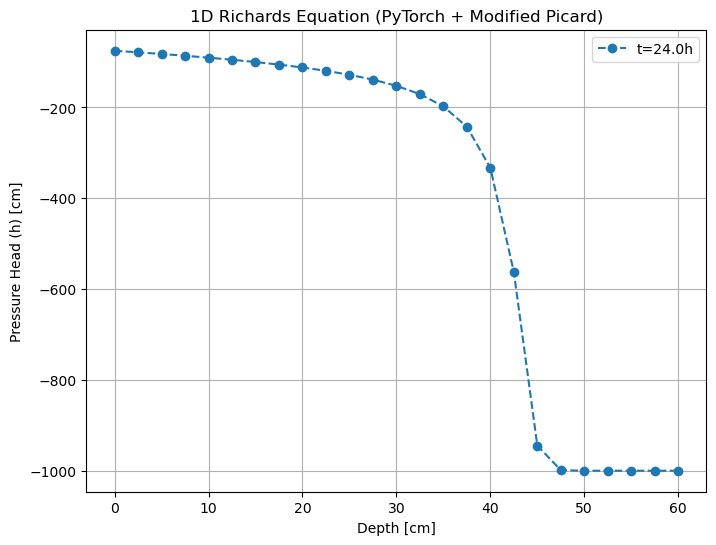

In [235]:
def solve_richards_pytorch():
    # Set device (CPU or GPU)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # --- Parameters ---
    L, dz = 60.0, 2.5
    T, dt = 3600*24, 100 # seconds
    z = torch.arange(0, L + dz, dz, device=device)
    nz = len(z)
    
    # Soil Properties (Silt Loam)
    theta_s = torch.tensor(0.368, device=device)
    theta_r = torch.tensor(0.102, device=device)
    alpha = torch.tensor(0.0335, device=device)
    n_vg = torch.tensor(2, device=device)
    m_vg = 1 - 1/n_vg
    Ks = torch.tensor(0.00922, device=device) # Saturated hydraulic conductivity [cm/s]
    
    # Initial & Boundary Conditions
    h = torch.full((nz,), -1000.0, device=device)
    h_top = torch.tensor(-75.0, device=device)
    h_bot = torch.tensor(-1000.0, device=device)
    h[0] = h_top
    h[-1] = h_bot
    
    tol = 1e-4
    max_iter = 50

    # --- Constitutive Functions using Torch ---
    def get_theta(h_val):
        se = torch.pow(1 + torch.pow(alpha * torch.abs(h_val), n_vg), -m_vg)
        return torch.where(h_val < 0, theta_r + (theta_s - theta_r) * se, theta_s)

    def get_K(h_val):
        se = torch.pow(1 + torch.pow(alpha * torch.abs(h_val), n_vg), -m_vg)
        K = Ks * torch.pow(se, 0.5) * torch.pow(1 - torch.pow(1 - torch.pow(se, 1/m_vg), m_vg), 2)
        return torch.where(h_val < 0, K, Ks)

    def get_C(h_val):
        # We can use autograd here, but for speed in a loop, the analytical form is used:
        abs_h = torch.abs(h_val)
        num = alpha * n_vg * m_vg * (theta_s - theta_r) * torch.pow(alpha * abs_h, n_vg - 1)
        den = torch.pow(1 + torch.pow(alpha * abs_h, n_vg), m_vg + 1)
        return torch.where(h_val < 0, num / den, torch.tensor(1e-10, device=device))

    # --- Simulation Loop ---
    t = 0.0
    plt.figure(figsize=(8, 6))
    
    while t < T:
        h_n = h.clone()
        theta_n = get_theta(h_n)
        h_m = h.clone()
        
        for m in range(max_iter):
            C_m = get_C(h_m)
            K_m = get_K(h_m)
            theta_m = get_theta(h_m)
            
            # Interface Conductivities
            K_plus = 0.5 * (K_m[1:-1] + K_m[2:])
            K_minus = 0.5 * (K_m[1:-1] + K_m[:-2])
            
            # Building the Tridiagonal System (Ax = B)
            # Size is nz-2 because boundaries are fixed
            size = nz - 2
            A = torch.zeros((size, size), device=device)
            B = torch.zeros(size, device=device)
            
            # Fill A and B using vectorized operations where possible
            diag = C_m[1:-1]/dt + (K_plus + K_minus)/dz**2
            upper = -K_plus[:-1]/dz**2
            lower = -K_minus[1:]/dz**2
            
            A.as_strided([size], [size+1]).copy_(diag) # Diagonal
            A.as_strided([size-1], [size+1], 1).copy_(upper) # Upper
            A.as_strided([size-1], [size+1], size).copy_(lower) # Lower
            
            # Celia's Mass-Conservative RHS
            flux = (K_plus * (h_m[2:] - h_m[1:-1]) / dz - 
                    K_minus * (h_m[1:-1] - h_m[:-2]) / dz) / dz
            gravity = (K_plus - K_minus) / dz
            
            B = flux + gravity - (theta_m[1:-1] - theta_n[1:-1]) / dt
            
            # Solve for delta_h
            delta_h = torch.linalg.solve(A, B)
            
            h_m[1:-1] += delta_h
            
            if torch.max(torch.abs(delta_h)) < tol:
                break
                
        h = h_m.clone()
        t += dt
        
    plt.plot(z.cpu().numpy(), h.cpu().numpy(), '--o', label=f't={t/3600:.1f}h')

    plt.title("1D Richards Equation (PyTorch + Modified Picard)")
    plt.ylabel("Pressure Head (h) [cm]")
    plt.xlabel("Depth [cm]")
    plt.grid(True)
    plt.legend()
    plt.show()

    return z.cpu().numpy(), h.cpu().numpy()

if __name__ == "__main__":
    z_pic_pyt, h_pic_pyt = solve_richards_pytorch()

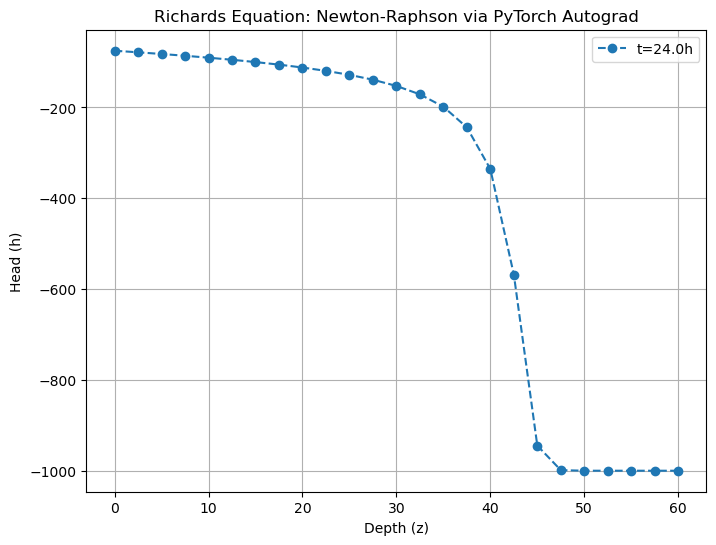

In [236]:
def solve_richards_newton_pytorch():
    # Setup
    L, dz = 60.0, 2.5
    T, dt = 3600*24, 400 # seconds
    z = torch.arange(0, L + dz, dz)
    nz = len(z)
    
    # Soil Parameters (van Genuchten)
    ts, tr, alpha, n_vg, Ks = 0.368, 0.102, 0.0335, 2, 0.00922
    m_vg = 1 - 1/n_vg

    # Initial Condition
    h = torch.full((nz,), -1000.0, requires_grad=True)
    h_top = torch.tensor(-75.0)
    h_bot = torch.tensor(-1000.0)

    h_n = h.detach().clone()
    
    def get_theta(h_val):
        abs_h = torch.abs(h_val)
        se = torch.pow(1 + torch.pow(alpha * abs_h, n_vg), -m_vg)
        return torch.where(h_val < 0, tr + (ts - tr) * se, ts)

    def get_K(h_val):
        abs_h = torch.abs(h_val)
        se = torch.pow(1 + torch.pow(alpha * abs_h, n_vg), -m_vg)
        K = Ks * torch.pow(se, 0.5) * torch.pow(1 - torch.pow(1 - torch.pow(se, 1/m_vg), m_vg), 2)
        return torch.where(h_val < 0, K, Ks)

    # Residual Function
    def compute_residual(h_curr, h_prev):
        theta_curr = get_theta(h_curr)
        theta_prev = get_theta(h_prev)
        K = get_K(h_curr)
        
        # Mid-point conductivities
        K_plus = 0.5 * (K[1:-1] + K[2:])
        K_minus = 0.5 * (K[1:-1] + K[:-2])
        
        # Fluxes (Mixed Form)
        flux = (K_plus * (h_curr[2:] - h_curr[1:-1])/dz - 
                K_minus * (h_curr[1:-1] - h_curr[:-2])/dz) / dz
        gravity = (K_plus - K_minus) / dz
        
        res = torch.zeros_like(h_curr)
        # Interior nodes residual
        res[1:-1] = (theta_curr[1:-1] - theta_prev[1:-1])/dt - (flux + gravity)
        # Dirichlet Boundaries (Residual should be 0 if h matches boundary)
        res[0] = h_curr[0] - (h_top) # Top boundary
        res[-1] = h_curr[-1] - (h_bot) # Bottom boundary
        return res

    # Simulation Loop
    t = 0.0
    plt.figure(figsize=(8, 6))
    
    while t < T:
        for m in range(10): # Newton iterations
            res = compute_residual(h, h_n)
            
            # Compute Jacobian using autograd.functional
            # res is a vector, h is a vector -> J is [nz, nz]
            J = torch.autograd.functional.jacobian(lambda x: compute_residual(x, h_n), h)
            
            # Newton Update: delta_h = - J^-1 * res
            delta_h = torch.linalg.solve(J, -res)
            
            # Update h (in-place update requires temporarily disabling grad)
            with torch.no_grad():
                h += delta_h
            
            if torch.norm(delta_h) < 1e-4:
                break
        
        h_n = h.detach().clone()
        t += dt
    plt.plot(z.numpy(), h.detach().numpy(),'--o',label=f't={t/3600:.1f}h')

    plt.title("Richards Equation: Newton-Raphson via PyTorch Autograd")
    plt.ylabel("Head (h)")
    plt.xlabel("Depth (z)")
    plt.legend()
    plt.grid(True)
    plt.show()

    return z.numpy(), h.detach().numpy()

z_new_pyt, h_new_pyt = solve_richards_newton_pytorch()

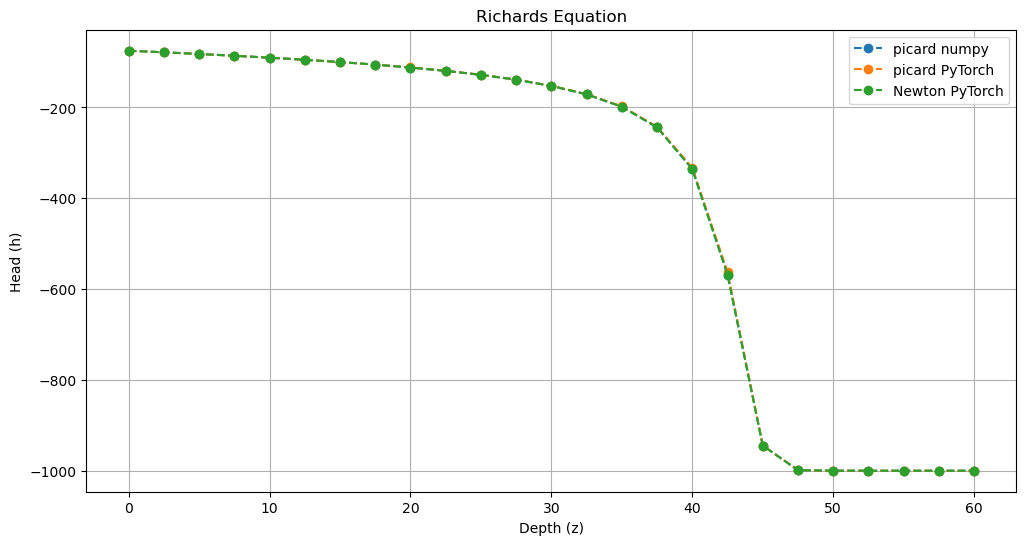

In [244]:
plt.figure(figsize=(12,6))
plt.plot(z_picard,h_picard,'--o',label=f'picard numpy')
plt.plot(z_pic_pyt,h_pic_pyt,'--o',label=f'picard PyTorch')
plt.plot(z_new_pyt,h_new_pyt,'--o',label=f'Newton PyTorch')

plt.title("Richards Equation")
plt.ylabel("Head (h)")
plt.xlabel("Depth (z)")
plt.legend()
plt.grid(True)
plt.show()

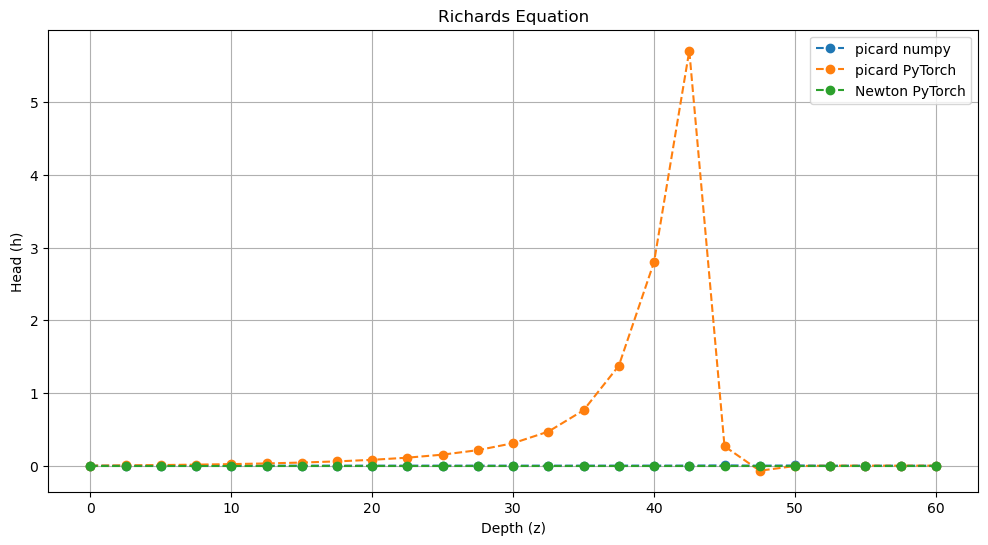

In [246]:
plt.figure(figsize=(12,6))
plt.plot(z_picard,h_picard-h_new_pyt,'--o',label=f'picard numpy')
plt.plot(z_pic_pyt,h_pic_pyt-h_new_pyt,'--o',label=f'picard PyTorch')
plt.plot(z_new_pyt,h_new_pyt-h_new_pyt,'--o',label=f'Newton PyTorch')

plt.title("Richards Equation")
plt.ylabel("Head (h)")
plt.xlabel("Depth (z)")
plt.legend()
plt.grid(True)
plt.show()

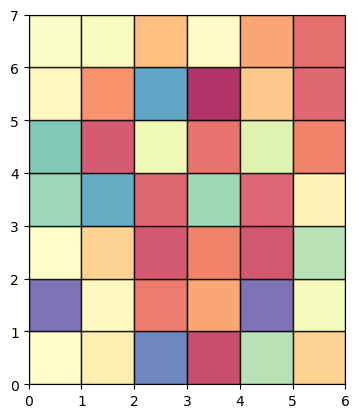

In [225]:
fig, ax = plt.subplots()
ax.set_xlim(0, 6)
ax.set_ylim(0, 7)

patches = []

# Create a 6×7 grid of 1×1 squares
for x in range(6):
    for y in range(7):
        # base square
        square = np.array([[0,0], [1,0], [1,1], [0,1]])
        # shift it to (x, y)
        square = square + np.array([x, y])
        patches.append(Polygon(square, edgecolor='black'))

# Color each cell randomly
colors = np.random.rand(len(patches))
collection = PatchCollection(
    patches,
    cmap='Spectral',
    alpha=0.8,
    match_original=True
)
collection.set_array(colors)

ax.add_collection(collection)
ax.set_aspect('equal')  # ensures squares stay square
plt.show()


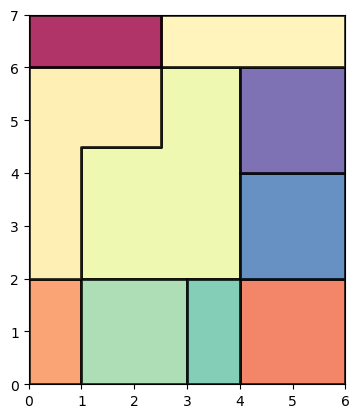

In [226]:
fig, ax = plt.subplots()
ax.axis([0, 6, 0, 7])

patches = []

array = np.array(((0,0), (1,0), (1,2), (0,2)))
shape = Polygon(array, lw = 2,edgecolor='black')
patches.append(shape)

array = np.array(((4,0), (6,0), (6,2), (4,2)))
shape = Polygon(array, lw = 2,edgecolor='black')
patches.append(shape)

array = np.array(((1,2), (4,2), (4,6), (2.5,6), (2.5,4.5), (1,4.5)))
shape = Polygon(array, lw = 2,edgecolor='black')
patches.append(shape)

array = np.array(((1,0),(3,0),(3,2),(1,2)))
shape = Polygon(array, lw = 2,edgecolor='black')
patches.append(shape)

array = np.array(((3,0),(4,0),(4,2),(3,2)))
shape = Polygon(array, lw = 2,edgecolor='black')
patches.append(shape)

array = np.array(((4,2),(6,2),(6,4),(4,4)))
shape = Polygon(array, lw = 2,edgecolor='black')
patches.append(shape)

array = np.array(((4,4),(6,4),(6,6),(4,6)))
shape = Polygon(array, lw = 2,edgecolor='black')
patches.append(shape)

array = np.array(((2.5,6),(6,6),(6,7),(2.5,7)))
shape = Polygon(array, lw = 2,edgecolor='black')
patches.append(shape)

array = np.array(((0,2),(1,2),(1,4.5),(2.5,4.5),(2.5,6),(0,6)))
shape = Polygon(array, lw = 2,edgecolor='black')
patches.append(shape)

array = np.array(((0,6),(2.5,6),(2.5,7),(0,7)))
shape = Polygon(array, lw = 2,edgecolor='black')
patches.append(shape)

colors = np.random.rand(len(patches))
p = PatchCollection(patches,cmap='Spectral',alpha=0.8,match_original = True)
p.set_array(colors)
ax.add_collection(p)
ax.set_aspect('equal')  # ensures squares stay square
plt.show()

In [534]:
# --- 1. SOIL PHYSICS (Van Genuchten Parameters) ---
alpha = 0.0335   # 1/cm
n_vg = 2    # dimensionless
m_vg = 1 - 1/n_vg
theta_r = 0.102
theta_s = 0.368
Ks = 0.00922          # Saturated hydraulic conductivity [cm/s]

def get_theta(h,k):
    if h >= 0: return theta_s[k]
    return theta_r[k] + (theta_s[k] - theta_r[k]) / (1 + (alpha[k] * abs(h))**n_vg[k])**m_vg[k]

def get_K(h,k):
    if h >= 0: return Ks[k]
    Se = (get_theta(h,k) - theta_r[k]) / (theta_s[k] - theta_r[k])
    return Ks[k] * Se**0.5 * (1 - (1 - Se**(1/m_vg[k]))**m_vg[k])**2

def get_C(h,k):
    """Specific Moisture Capacity dTheta/dh"""
    if h >= 0: return 1e-10 # Small value for stability in saturated zones
    abs_h = abs(h)
    num = (theta_s[k] - theta_r[k]) * m_vg[k] * n_vg[k] * (alpha[k]**n_vg[k]) * (abs_h**(n_vg[k]-1))
    den = (1 + (alpha[k] * abs_h)**n_vg[k])**(m_vg[k] + 1)
    return num / den

# G_ij = (Width of shared edge * Thickness of layer) / Distance between centers
def get_G_lateral(i, j, k):
    width = W_ij[i][j]   # Shared edge of the pentagon
    dist = L_ij[i][j]    # Distance between prism centers
    return (width * dz[k]) / dist

# --- 2. DOMAIN DEFINITION ---
n_prisms = 7
n_layers = 5
total_cells = n_prisms * n_layers

# Adjacency List: Which prism i is connected to which prism j
adj_prisms = {
    0: [1,2,3,4,5,6], 1: [0, 2], 2: [0, 2, 3], 3: [0, 2], 4: [0, 5], 5: [0, 4], 6: [0]
}
A_ij = {
    0: 9.75, 1: 3.5, 2: 4, 3: 4, 4: 2, 5: 4, 6: 6.25}

W_ij = {0:[0, 1.5, 2, 2, 1, 2, 5.5], # For the same polygon position 0
        1:[1.5, 0, 2, 0, 0, 0, 0],
        2:[2, 2, 0, 2, 0, 0, 0],
        3:[2, 0, 2, 0, 0, 0, 0],
        4:[1, 0, 0, 0, 0, 2, 0],
        5:[2, 0, 0, 0, 2, 0, 0],
        6:[5.5, 0, 0, 0, 0, 0, 0]} # Edge widths for the 7 prisms
L_ij = {0:[0, 4.42, 3.44, 3.44, 5.87, 3.44, 1.45],
        1:[4.42, 0, 1.87, 0, 0, 0, 0],
        2:[3.44, 1.87, 0, 2, 0, 0, 0],
        3:[3.44, 0, 2, 0, 0, 0, 0],
        4:[5.87, 0, 0, 0, 0, 2.5, 0],
        5:[3.44, 0, 0, 0, 2.5, 0, 0],
        6:[1.45, 0, 0, 0, 0, 0, 0]} # Distance to neighbors

dz = [0.1, 0.1, 0.25, 0.5, 0.15]      # 4 Layers of varying thickness
n_layers = len(dz)

In [535]:
# --- 1. SOIL PHYSICS (Van Genuchten Parameters) ---
alpha = np.full(n_layers, alpha)
n_vg = np.full(n_layers, n_vg)
m_vg = np.full(n_layers, m_vg)
theta_r = np.full(n_layers, theta_r)
theta_s = np.full(n_layers, theta_s)
Ks = np.full(n_layers, Ks)

In [536]:
# --- 1. DEFINE RAINFALL EVENT ---
# Intensity in m/s (example: 20 mm/hr)
rainfall_intensity = 0.1/1000/3600
print(rainfall_intensity)

def apply_top_boundary(R, n_prisms, n_layers, Ai):
    k_top = n_layers - 1
    for i in range(n_prisms):
        idx = k_top * n_prisms + i
        
        # Calculate flux: Area * Intensity
        # Note: In Richards equation, infiltration is a positive source
        Q_rain = Ai[i] * rainfall_intensity
        
        # Add to the Residual vector for the top cells
        R[idx] += Q_rain
    return R

# --- 2. INTEGRATION INTO SOLVER LOOP ---
# Inside your 'while not converged' loop:
# A, R = assemble_internal_terms(h_m)
# R = apply_top_boundary(R, h_m, n_prisms, n_layers, Ai)
# dh = spsolve(A, R)

2.777777777777778e-08


In [537]:
def solve_multi_column(h_n, dt, h_top_constant, h_bottom_constant, max_iter):
    h_m = h_n.copy()
    
    for iteration in range(max_iter):
        if iteration == max_iter-1: print('Reached max iteration before convergence')
        LHS = lil_matrix((total_cells, total_cells))
        RHS = np.zeros(total_cells)
        RHS = apply_top_boundary(RHS, n_prisms, n_layers, A_ij)
        #print(RHS)
        #break
        for k in range(n_layers):
            for i in range(n_prisms):
                idx_i = k * n_prisms + i
                
                # 1. Mass Accumulation Term (Celia et al. Formulation)
                V_ik = A_ij[i] * dz[k]
                Ci = get_C(h_m[idx_i],k)
                theta_m = get_theta(h_m[idx_i],k)
                theta_n = get_theta(h_n[idx_i],k)
                
                LHS[idx_i, idx_i] += V_ik * Ci / dt
                RHS[idx_i] -= (V_ik / dt) * (theta_m - theta_n)

                # 2. Vertical Fluxes (Z-direction)
                for direction in [-1, 1]: # -1 is layer below, 1 is layer above
                    adj_k = k + direction
                    if 0 <= adj_k < n_layers:
                        adj_k_idx = adj_k * n_prisms + i  
                        # Harmonic Mean of K
                        K_face = 2 / (1/get_K(h_m[idx_i],k) + 1/get_K(h_m[adj_k_idx],k))
                        dz_avg = (dz[k] + dz[adj_k]) / 2
                        G_v = A_ij[i] / dz_avg
                    
                        # LHS Matrix Coefficients
                        LHS[idx_i, idx_i] += G_v * K_face
                        LHS[idx_i, adj_k_idx] -= G_v * K_face
                    
                        # RHS Residual (including gravity +1)
                        # Note: gravity acts downward
                        grad_h = (h_m[adj_k_idx] - h_m[idx_i])
                        gravity = 1.0 if direction == 1 else -1
                        RHS[idx_i] += G_v * K_face * (grad_h + gravity)
        
                    '''else:
                        # --- BOUNDARY CONDITION LOGIC ---
                        # Determine if we are at top or bottom
                        if direction == 1: # Top Boundary
                            h_bound = h_top_constant  # Define this outside the loop
                            dist_to_bound = dz[k] / 2
                            gravity = 1.0
                        else: # Bottom Boundary
                            h_bound = h_bottom_constant # Define this outside the loop
                            dist_to_bound = dz[k] / 2
                            gravity = -1.0
                            
                        # Conductivity at the boundary face
                        K_face = get_K(h_bound) # Or use h_bound if preferred
                        G_v = A_ij[i] / dist_to_bound
                        
                        # For a fixed Head (Dirichlet), the boundary term moves to the RHS
                        # because h_bound is not a variable to solve for.
                        # Flow = G_v * K_face * [(h_bound - h_m[idx_i]) + gravity * dist_to_bound]
                        
                        LHS[idx_i, idx_i] += G_v * K_face
                        # RHS contribution: G_v * K_face * (h_boundary_diff + gravity_effect)
                        RHS[idx_i] += G_v * K_face * ((h_bound - h_m[idx_i]) + gravity)'''

                # 3. Horizontal Fluxes
                for j in adj_prisms[i]:
                    if i == j: continue
                    idx_j = k * n_prisms + j
                    K_face = 2/(1/get_K(h_m[idx_i],k) + 1/get_K(h_m[idx_j],k))
                    conductance = get_G_lateral(i, j, k) * K_face
                    
                    LHS[idx_i, idx_i] += conductance
                    LHS[idx_i, idx_j] -= conductance
                    RHS[idx_i] += conductance * (h_m[idx_j] - h_m[idx_i])
                    
        
        # Solve and update
        dh = spsolve(LHS.tocsr(), RHS)
        h_m += dh
        #print(h_m)
        
        if np.linalg.norm(dh, np.inf) < 1e-4:
            #print('convergence dh', np.max(np.abs(dh)))
            break
            
    return h_m

In [538]:
def plot_wetting_front(history_h, dz):
    # Calculate cumulative depth for the y-axis (mid-points of layers)
    depths = np.cumsum(dz) - (np.array(dz) / 2)
    times = np.arange(history_h.shape[1])
    
    plt.figure(figsize=(10, 6))
    # Use 'shading=gouraud' to smooth the front movement
    plt.pcolormesh(times, -depths, history_h, cmap='Blues', shading='auto')
    
    plt.colorbar(label='Pressure Head (h) [m]')
    plt.ylabel('Depth below surface [m]')
    plt.xlabel('Time Step')
    plt.title('Wetting Front Propagation (Center Prism)')
    plt.gca().invert_yaxis() # Depth increases downwards
    plt.show()

In [539]:
# --- 3. INITIAL CONDITIONS ---
h_old  = np.full(total_cells, -1000.0) # Start with dry soil (head = -1m)
dt = 400 # sec time step
h_old

array([-1000., -1000., -1000., -1000., -1000., -1000., -1000., -1000.,
       -1000., -1000., -1000., -1000., -1000., -1000., -1000., -1000.,
       -1000., -1000., -1000., -1000., -1000., -1000., -1000., -1000.,
       -1000., -1000., -1000., -1000., -1000., -1000., -1000., -1000.,
       -1000., -1000., -1000.])

In [540]:
h_new = solve_multi_column(h_old, dt,h_top,h_bot,100)
print(h_new)

[ -999.32174724  -999.32174724  -999.32174724  -999.32174724
  -999.32174724  -999.32174724  -999.32174724  -999.89631864
  -999.89631864  -999.89631864  -999.89631864  -999.89631864
  -999.89631864  -999.89631864 -1000.03669509 -1000.03669509
 -1000.03669509 -1000.03669509 -1000.03669509 -1000.03669509
 -1000.03669509  -999.41238646  -999.41238646  -999.41238646
  -999.41238646  -999.41238646  -999.41238646  -999.41238646
  -993.12646752  -993.12646752  -993.12646752  -993.12646752
  -993.12646752  -993.12646752  -993.12646752]


In [541]:
# Initialize storage
time_steps = 50
history_h = np.zeros((n_layers, time_steps))

for t in range(time_steps):
    # Solve for the entire 5-prism domain
    h_new = solve_multi_column(h_old,h_top,h_bot, dt, 100)
    
    # Global index I = k * n_prisms + i
    for k in range(n_layers):
        history_h[k, t] = h_new[k * n_prisms + 2]
    
    h_old = h_new

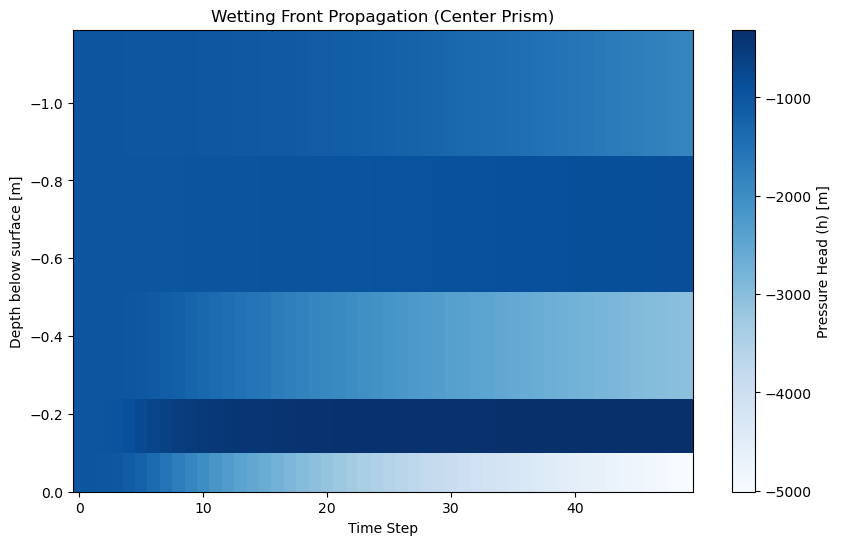

In [542]:
plot_wetting_front(history_h, dz)

# Example 3D regular grid

In [2]:
# --- 1. SOIL PHYSICS (Van Genuchten Parameters) ---
alpha = 0.067*100  # 1/m
n_vg = 2    # dimensionless
m_vg = 1 - 1/n_vg
theta_r = 0.075
theta_s = 0.287
Ks = 1/100/3600         # Saturated hydraulic conductivity [cm/h] --> [m/s]

def get_theta(h,k):
    if h >= 0: return theta_s[k]
    return theta_r[k] + (theta_s[k] - theta_r[k]) / (1 + (alpha[k] * abs(h))**n_vg[k])**m_vg[k]

def get_K(h,k):
    if h >= 0: return Ks[k]
    Se = (get_theta(h,k) - theta_r[k]) / (theta_s[k] - theta_r[k])
    return Ks[k] * Se**0.5 * (1 - (1 - Se**(1/m_vg[k]))**m_vg[k])**2

def get_C(h,k):
    """Specific Moisture Capacity dTheta/dh"""
    if h >= 0: return 1e-10 # Small value for stability in saturated zones
    abs_h = abs(h)
    num = (theta_s[k] - theta_r[k]) * m_vg[k] * n_vg[k] * (alpha[k]**n_vg[k]) * (abs_h**(n_vg[k]-1))
    den = (1 + (alpha[k] * abs_h)**n_vg[k])**(m_vg[k] + 1)
    return num / den

# G_ij = (Width of shared edge * Thickness of layer) / Distance between centers
def get_G_lateral(i, j, k):
    width = W_ij[i][j]   # Shared edge of the pentagon
    dist = L_ij[i][j]    # Distance between prism centers
    return (width * dz[k]) / dist

In [3]:
Ks

2.777777777777778e-06

In [4]:
# --- 2. DOMAIN DEFINITION ---
n_prisms = 6*7
n_layers = 10
total_cells = n_prisms * n_layers

In [5]:
def generate_regular_grid(rows=6, cols=7):
    adj_prisms = {}
    A_ij = {}
    W_ij = np.zeros((rows * cols, rows * cols))
    L_ij = np.zeros((rows * cols, rows * cols))

    for r in range(rows):
        for c in range(cols):
            i = r * cols + c
            A_ij[i] = 0.04*0.04  # Area of 1x1 cell
            adj_prisms[i] = []

            # Check neighbors: Top, Bottom, Left, Right
            neighbors = [
                (r - 1, c), (r + 1, c), (r, c - 1), (r, c + 1)
            ]

            for nr, nc in neighbors:
                if 0 <= nr < rows and 0 <= nc < cols:
                    j = nr * cols + nc
                    adj_prisms[i].append(j)
                    W_ij[i][j] = 0.04  # Shared edge width
                    L_ij[i][j] = 0.04  # Distance between centers

    # Convert matrices to dictionaries to match your class structure
    W_dict = {i: list(row) for i, row in enumerate(W_ij)}
    L_dict = {i: list(row) for i, row in enumerate(L_ij)}

    return adj_prisms, A_ij, W_dict, L_dict

# Generate parameters
adj, areas, widths, lengths = generate_regular_grid(6, 7)

In [6]:
adj_prisms=adj
A_ij=areas
W_ij=widths
L_ij=lengths

In [7]:
dz = np.full(n_layers,0.04)
print(dz)

[0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04]


In [8]:
# --- 1. SOIL PHYSICS (Van Genuchten Parameters) ---
alpha = np.full(n_layers, alpha)
n_vg = np.full(n_layers, n_vg)
m_vg = np.full(n_layers, m_vg)
theta_r = np.full(n_layers, theta_r)
theta_s = np.full(n_layers, theta_s)
Ks = np.full(n_layers, Ks)

In [21]:
np.full((n_layers,n_prisms), 876).shape

(10, 42)

In [9]:
# --- 1. DEFINE RAINFALL EVENT ---
# Intensity in m/s (example: 2 cm/day)
rainfall_intensity = 0.2/100/86400
print(rainfall_intensity)

def apply_top_boundary(R, n_prisms, n_layers, Ai):
    k_top = n_layers - 1
    for i in range(n_prisms):
        idx = k_top * n_prisms + i
        
        # Calculate flux: Area * Intensity
        # Note: In Richards equation, infiltration is a positive source
        Q_rain = Ai[i] * rainfall_intensity
        
        # Add to the Residual vector for the top cells
        R[idx] += Q_rain
    return R

2.3148148148148148e-08


In [10]:
import warnings
warnings.filterwarnings("error")

In [11]:
def solve_multi_column(h_n, dt, h_top_constant, h_bottom_constant, max_iter):
    h_m = h_n.copy()
    
    for iteration in range(max_iter):
        if iteration == max_iter-1: print('Reached max iteration before convergence')
        LHS = lil_matrix((total_cells, total_cells))
        RHS = np.zeros(total_cells)
        RHS = apply_top_boundary(RHS, n_prisms, n_layers, A_ij)
        #print(RHS)
        #break
        for k in range(n_layers):
            for i in range(n_prisms):
                idx_i = k * n_prisms + i
                
                # 1. Mass Accumulation Term (Celia et al. Formulation)
                V_ik = A_ij[i] * dz[k]
                Ci = get_C(h_m[idx_i],k)
                theta_m = get_theta(h_m[idx_i],k)
                theta_n = get_theta(h_n[idx_i],k)
                
                LHS[idx_i, idx_i] += V_ik * Ci / dt
                RHS[idx_i] -= (V_ik / dt) * (theta_m - theta_n)

                # 2. Vertical Fluxes (Z-direction)
                for direction in [-1, 1]: # -1 is layer below, 1 is layer above
                    adj_k = k + direction
                    if 0 <= adj_k < n_layers:
                        adj_k_idx = adj_k * n_prisms + i  
                        # Harmonic Mean of K
                        try:
                            #K_face = 2 / (1/get_K(h_m[idx_i],k) + 1/get_K(h_m[adj_k_idx],adj_k))
                            K_face = (get_K(h_m[idx_i],k)+get_K(h_m[adj_k_idx],adj_k))/2
                        except RuntimeWarning:
                            print(f'vertical 2/(1/({get_K(h_m[idx_i],k)})+1/({get_K(h_m[adj_k_idx],adj_k)})) | idx_i:{idx_i}, adj_k:{adj_k}, h:{h_m[adj_k_idx]}')
                            break
                        dz_avg = (dz[k] + dz[adj_k]) / 2
                        G_v = A_ij[i] / dz_avg
                    
                        # LHS Matrix Coefficients
                        LHS[idx_i, idx_i] += G_v * K_face
                        LHS[idx_i, adj_k_idx] -= G_v * K_face
                    
                        # RHS Residual (including gravity +1)
                        # Note: gravity acts downward
                        grad_h = (h_m[adj_k_idx] - h_m[idx_i])
                        gravity = 1.0 if direction == 1 else -1
                        RHS[idx_i] += G_v * K_face * (grad_h + gravity)
        
                    '''else:
                        # --- BOUNDARY CONDITION LOGIC ---
                        # Determine if we are at top or bottom
                        if direction == 1: # Top Boundary
                            h_bound = h_top_constant  # Define this outside the loop
                            dist_to_bound = dz[k] / 2
                            gravity = 1.0
                        else: # Bottom Boundary
                            h_bound = h_bottom_constant # Define this outside the loop
                            dist_to_bound = dz[k] / 2
                            gravity = -1.0
                            
                        # Conductivity at the boundary face
                        K_face = get_K(h_bound) # Or use h_bound if preferred
                        G_v = A_ij[i] / dist_to_bound
                        
                        # For a fixed Head (Dirichlet), the boundary term moves to the RHS
                        # because h_bound is not a variable to solve for.
                        # Flow = G_v * K_face * [(h_bound - h_m[idx_i]) + gravity * dist_to_bound]
                        
                        LHS[idx_i, idx_i] += G_v * K_face
                        # RHS contribution: G_v * K_face * (h_boundary_diff + gravity_effect)
                        RHS[idx_i] += G_v * K_face * ((h_bound - h_m[idx_i]) + gravity)'''

                # 3. Horizontal Fluxes
                for j in adj_prisms[i]:
                    if i == j: continue
                    idx_j = k * n_prisms + j
                    try:
                        #K_face = 2/(1/get_K(h_m[idx_i],k) + 1/get_K(h_m[idx_j],k))
                        K_face = (get_K(h_m[idx_i],k)+get_K(h_m[idx_j],k))/2
                    except RuntimeWarning:
                        print(f'horizontal 2/(1/({get_K(h_m[idx_i],k)})+1/({get_K(h_m[idx_j],k)})) | idx_i:{idx_i}, idx_j:{idx_j}, h:{h_m[idx_j]}')
                        break
                    conductance = get_G_lateral(i, j, k) * K_face
                    
                    LHS[idx_i, idx_i] += conductance
                    LHS[idx_i, idx_j] -= conductance
                    RHS[idx_i] += conductance * (h_m[idx_j] - h_m[idx_i])
                    
        
        # Solve and update
        dh = spsolve(LHS.tocsr(), RHS)
        h_m += dh
        #print(h_m)
        
        if np.linalg.norm(dh, np.inf) < 1e-4:
            #print('convergence dh', np.max(np.abs(dh)))
            break
            
    return h_m

In [12]:
def plot_wetting_front(history_h, dz):
    # Calculate cumulative depth for the y-axis (mid-points of layers)
    depths = np.cumsum(dz) - (np.array(dz) / 2)
    times = np.arange(history_h.shape[1])
    
    plt.figure(figsize=(10, 6))
    # Use 'shading=gouraud' to smooth the front movement
    plt.pcolormesh(times, -depths, history_h, cmap='Blues', shading='auto')
    
    plt.colorbar(label='Pressure Head (h) [m]')
    plt.ylabel('Depth below surface [m]')
    plt.xlabel('Time Step')
    plt.title('Wetting Front Propagation (Center Prism)')
    plt.gca().invert_yaxis() # Depth increases downwards
    plt.show()

In [13]:
# --- 3. INITIAL CONDITIONS ---
h_old  = np.full(total_cells, -10.0) # Start with dry soil (head = -1000cm)
dt = 864 # sec time step

In [15]:
h_new = solve_multi_column(h_old, dt,-75,-1000,100)
h_old = h_new
#print(h_new)

In [17]:
# Initialize storage
time_steps = 100
history_h = np.zeros((n_layers, time_steps))

for t in range(time_steps):
    # Solve for the entire 5-prism domain
    h_new = solve_multi_column(h_old,-75,-1000, dt, 100)
    
    # Global index I = k * n_prisms + i
    for k in range(n_layers):
        history_h[k, t] = h_new[k * n_prisms]
    
    h_old = h_new

Reached max iteration before convergence
Reached max iteration before convergence
Reached max iteration before convergence
Reached max iteration before convergence
Reached max iteration before convergence
Reached max iteration before convergence
Reached max iteration before convergence
Reached max iteration before convergence
Reached max iteration before convergence
Reached max iteration before convergence
Reached max iteration before convergence
Reached max iteration before convergence
Reached max iteration before convergence
Reached max iteration before convergence
Reached max iteration before convergence
Reached max iteration before convergence


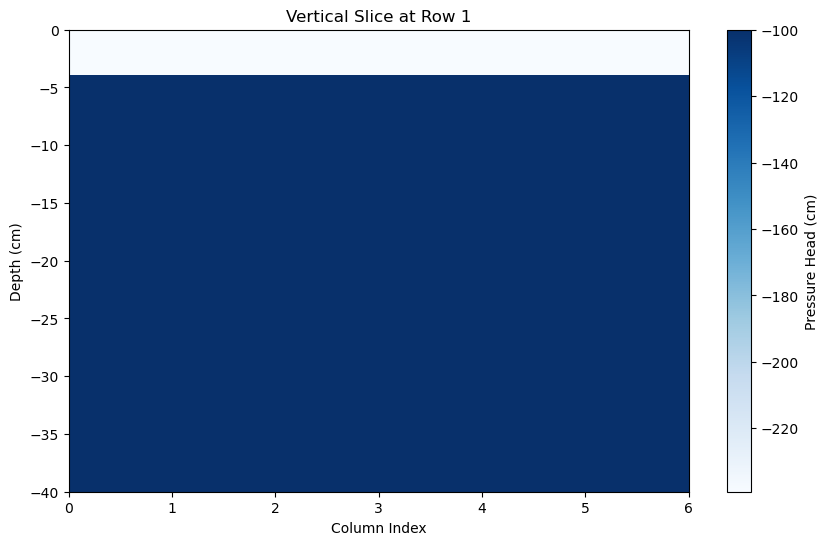

In [1024]:
def plot_vertical_slice(h_new, row_to_slice, n_layers, dz,rows=6, cols=7):
    # 1. Reshape h_new to (Layers, Rows, Columns)
    # The solver has n_layers and n_prisms (which is rows * cols)
    h_reshaped = h_new.reshape((n_layers, rows, cols))
    
    # 2. Extract the slice along a specific row (East-West slice)
    # This gives us a 2D array of (Layers, Columns)
    slice_data = h_reshaped[:, row_to_slice, :]
    
    # 3. Create coordinates for the plot
    # x = column index, y = cumulative depth (negative dz)
    x = np.arange(cols)
    y = np.cumsum(dz[::-1])[::-1] # Approximate depths from dz
    
    plt.figure(figsize=(10, 6))
    im = plt.imshow(np.flipud(slice_data)*10, aspect='auto', cmap='Blues', 
                    extent=[0, cols-1, -sum(dz*100), 0])
    
    plt.colorbar(im, label='Pressure Head (cm)')
    plt.title(f'Vertical Slice at Row {row_to_slice}')
    plt.xlabel('Column Index')
    plt.ylabel('Depth (cm)')
    plt.show()

# Example usage:
plot_vertical_slice(h_new, 1, n_layers, dz,6,7)